**Business Need for Fraud Detection in Financial Transactions**

Problem Statement

Financial institutions, e-commerce platforms, and online payment systems face significant losses due to fraudulent transactions. Fraudsters use stolen credit card details, fake identities, and other malicious tactics to perform unauthorized transactions.

Why is Fraud Detection Important?

Financial Loss Prevention: Banks and businesses lose billions annually due to fraud.

Customer Trust & Retention: Ensuring transaction security enhances customer confidence.

Regulatory Compliance: Companies must comply with financial regulations to prevent fraud.

Operational Efficiency: Detecting fraud early saves investigation costs and reduces chargebacks.

Business Impact

Reduced Chargebacks & Losses 🏦

Early fraud detection minimizes financial losses.

Enhanced Security & Compliance 🔐

Detecting anomalies ensures compliance with anti-fraud regulations.

Improved Customer Experience 💳

Preventing fraud protects customer accounts and builds trust.

Objective of the Project

Analyze transaction data to identify patterns of fraudulent behavior.

Develop a Machine Learning model to detect fraud in real-time.

Improve accuracy using feature engineering and various ML algorithms.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE

In [15]:
# Load dataset
data = pd.read_csv("fraud_detection_sample.csv")

# Display first few rows
data.head()




,Time,Amount,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,Class
0,15795,4292.21,0.593101,-1.592994,0.126380,0.189706,0.333860,-1.535040,0.872197,-2.386930,-0.190872,-1.846573,0
1,860,2145.54,-0.309546,0.440475,1.938929,-0.661982,1.431367,-1.880010,-0.315087,-0.495878,-0.198196,-0.428655,0
2,76820,3754.60,0.326133,-0.019638,-1.000331,0.425887,1.081767,0.712712,-0.571746,1.097300,0.510157,1.029441,0
3,54886,3772.96,-1.251114,0.552490,-0.677745,0.019148,-1.312219,-1.883150,0.332608,-1.565648,1.272570,-0.336895,0
4,6265,516.52,0.924027,0.223914,0.513908,-0.641487,0.622070,-0.372319,0.933128,-3.007632,0.126314,-0.846434,0


In [16]:
#Summary statistics
data.describe()



,Time,Amount,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,Class
count,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,43048.78600,2470.166680,0.101780,0.067971,-0.003797,0.020542,-0.029602,0.062896,-0.074014,-0.075804,-0.000768,-0.035295,0.040000
std,25316.62397,1463.746948,0.987808,0.998566,0.978218,0.962385,1.011267,1.041071,0.991492,0.995217,0.992545,0.992164,0.196155
min,206.00000,24.160000,-2.896255,-2.921350,-3.019512,-2.635748,-2.991136,-2.929449,-2.839079,-3.007632,-3.176704,-2.833030,0.000000
25%,20662.50000,1146.270000,-0.559808,-0.610688,-0.621298,-0.660736,-0.640422,-0.728126,-0.715021,-0.766014,-0.654181,-0.668985,0.000000
50%,44343.50000,2463.615000,0.130537,0.033044,-0.011876,0.036045,-0.071291,0.078360,-0.087763,-0.012362,0.011646,-0.058539,0.000000
75%,65725.25000,3751.187500,0.728882,0.710820,0.640098,0.679584,0.608739,0.766002,0.536626,0.662881,0.628818,0.666721,0.000000
max,86202.00000,4998.590000,2.632382,3.193108,3.137749,3.109919,3.926238,2.868403,3.243093,2.196223,3.112910,2.935658,1.000000


In [17]:
#Create time in hours
data["Time_hours"] = data["Time"] / 3600
data.head()


,Time,Amount,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,Class,Time_hours
0,15795,4292.21,0.593101,-1.592994,0.126380,0.189706,0.333860,-1.535040,0.872197,-2.386930,-0.190872,-1.846573,0,4.387500
1,860,2145.54,-0.309546,0.440475,1.938929,-0.661982,1.431367,-1.880010,-0.315087,-0.495878,-0.198196,-0.428655,0,0.238889
2,76820,3754.60,0.326133,-0.019638,-1.000331,0.425887,1.081767,0.712712,-0.571746,1.097300,0.510157,1.029441,0,21.338889
3,54886,3772.96,-1.251114,0.552490,-0.677745,0.019148,-1.312219,-1.883150,0.332608,-1.565648,1.272570,-0.336895,0,15.246111
4,6265,516.52,0.924027,0.223914,0.513908,-0.641487,0.622070,-0.372319,0.933128,-3.007632,0.126314,-0.846434,0,1.740278


## EDA: Check class distribution

In [18]:
#Check fraud distribution
class_distribution = data["Class"].value_counts()

print(class_distribution)



Class
0    480
1     20
Name: count, dtype: int64


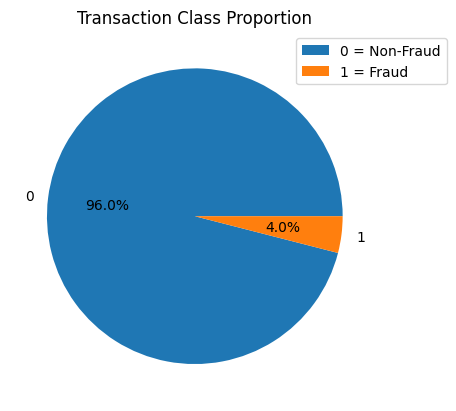

In [19]:
class_distribution.plot(kind="pie",autopct='%1.1f%%',ylabel="")
plt.title("Transaction Class Proportion")
plt.legend(["0 = Non-Fraud", "1 = Fraud"], loc="upper right",bbox_to_anchor=(1.2,1))

plt.show()



In this chart, most transactions are normal — about 96% are non-fraud, and only 4% are fraud. This shows the dataset is imbalanced, meaning fraud cases are very few compared to normal ones. Because of this, when we build a model, it may learn more about normal transactions and miss fraud cases, so we need special techniques like balancing methods and better evaluation metrics to detect fraud correctly.


In [20]:
Total_Amount = data.groupby("Class")["Amount"].sum()
print(Total_Amount)

Class
0    1185180.82
1      49902.52
Name: Amount, dtype: float64


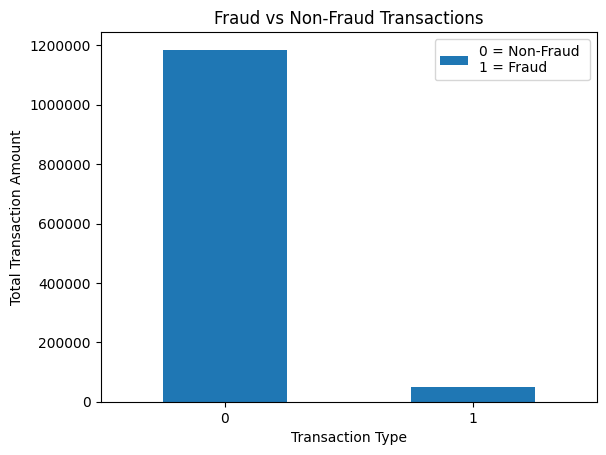

In [21]:
Total_Amount.plot(kind="bar")
plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Transaction Type")
plt.ylabel("Total Transaction Amount")
plt.legend(["0 = Non-Fraud \n1 = Fraud"], loc="upper right")
plt.xticks(rotation = 360)
plt.ticklabel_format(style="plain",axis="y")
plt.show()

This chart shows that the total transaction amount for non-fraud transactions (0) is much higher than for fraud transactions (1). It means most of the money flow comes from normal transactions, while fraud happens in a small portion of the total amount. This tells us that fraud cases are rare but still important to detect because even small fraud amounts can cause losses, so the model should focus on identifying these unusual transactions.

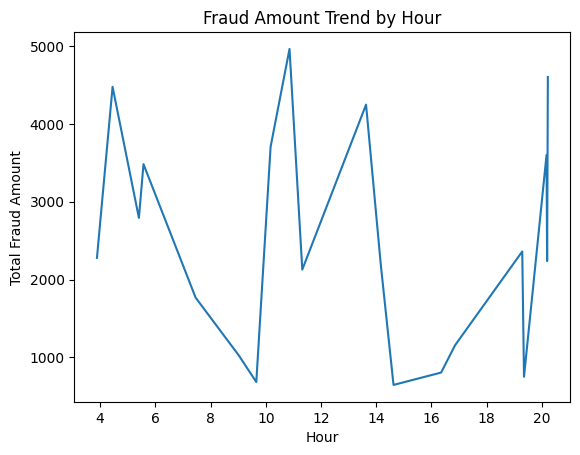

In [22]:

# Filter fraud transactions
fraud_data = data[data["Class"] == 1]

# Group by hour and sum amount
fraud_trend = fraud_data.groupby("Time_hours")["Amount"].sum()

# Plot
plt.figure()
plt.plot(fraud_trend.index, fraud_trend.values)

plt.xlabel("Hour")
plt.ylabel("Total Fraud Amount")
plt.title("Fraud Amount Trend by Hour")

plt.show()


This graph shows how fraud transaction amounts change during different hours of the day. We can see that fraud activity is not constant — it goes up and down, with some hours showing higher fraud amounts and others much lower. This means fraud tends to happen more at certain times, so banks or companies can monitor transactions more closely during these peak hours to reduce risk.

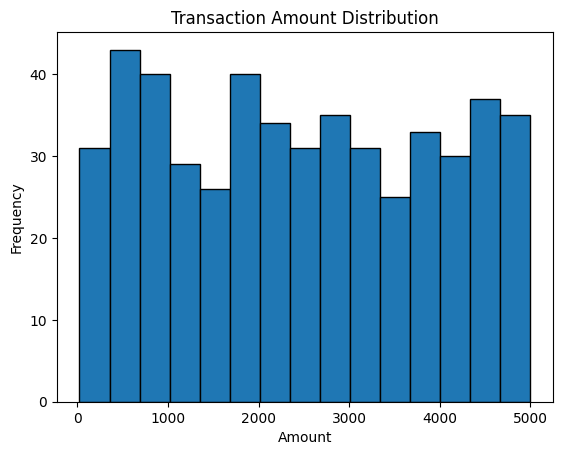

In [23]:


data['Amount'].hist( bins=15,edgecolor="black")
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.grid(False)
plt.ylabel("Frequency")
plt.show()

This chart shows how transaction amounts are spread across different values. We can see that transactions happen at many different amounts, from low to high, which means customers make payments of various sizes. There is no single amount where most transactions are concentrated, showing a wide distribution. This helps us understand normal spending patterns and can help detect unusual or suspicious transactions.

<Figure size 640x480 with 0 Axes>

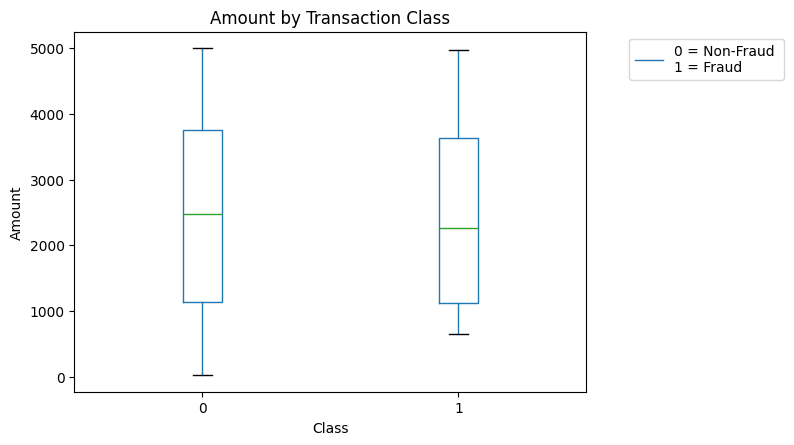

In [24]:
plt.figure()
data.boxplot(column='Amount', by='Class')
plt.title("Amount by Transaction Class")
plt.legend(["0 = Non-Fraud \n1 = Fraud"], loc="upper right",bbox_to_anchor=(1.4,1))
plt.suptitle("")
plt.xlabel("Class")
plt.ylabel("Amount")
plt.grid(False)
plt.show()


This box plot compares transaction amounts between non-fraud (0) and fraud (1) transactions. We can see that both have a wide range of amounts, but the typical (median) amounts are somewhat similar. This means fraud can happen at different transaction sizes, not only at very high amounts. So, we cannot rely only on transaction amount to detect fraud — other features are also important.


In [25]:

# Split features and target
      ##Features (inputs)
X = data.drop('Class', axis=1)

    #Target (output)
    
y = data['Class']

print(X.head())
print(y.head())


# Handle class imbalance using SMOTE
sm = SMOTE(random_state=42)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# Feature scaling
scaler = StandardScaler()

X_train_res = scaler.fit_transform(X_train_res)
X_test = scaler.transform(X_test)


# Model training with Random Forest
model = RandomForestClassifier(random_state=42)

model.fit(X_train_res, y_train_res)

# Predictions
y_pred = model.predict(X_test)





    Time   Amount        V1        V2        V3        V4        V5        V6  \
0  15795  4292.21  0.593101 -1.592994  0.126380  0.189706  0.333860 -1.535040   
1    860  2145.54 -0.309546  0.440475  1.938929 -0.661982  1.431367 -1.880010   
2  76820  3754.60  0.326133 -0.019638 -1.000331  0.425887  1.081767  0.712712   
3  54886  3772.96 -1.251114  0.552490 -0.677745  0.019148 -1.312219 -1.883150   
4   6265   516.52  0.924027  0.223914  0.513908 -0.641487  0.622070 -0.372319   

         V7        V8        V9       V10  Time_hours  
0  0.872197 -2.386930 -0.190872 -1.846573    4.387500  
1 -0.315087 -0.495878 -0.198196 -0.428655    0.238889  
2 -0.571746  1.097300  0.510157  1.029441   21.338889  
3  0.332608 -1.565648  1.272570 -0.336895   15.246111  
4  0.933128 -3.007632  0.126314 -0.846434    1.740278  
0    0
1    0
2    0
3    0
4    0
Name: Class, dtype: int64


In [26]:
# Model evaluation

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[93  3]
 [ 4  0]]
              precision    recall  f1-score   support

           0       0.96      0.97      0.96        96
           1       0.00      0.00      0.00         4

    accuracy                           0.93       100
   macro avg       0.48      0.48      0.48       100
weighted avg       0.92      0.93      0.93       100



In this step, the dataset was divided into input features and target, then split into training and testing data. Because fraud cases were very few, SMOTE was used to balance the data so the model could learn fraud patterns better. After that, feature scaling was applied and a Random Forest model was trained to predict fraud. The evaluation shows the model performs well for normal transactions but still struggles to correctly identify fraud cases, highlighting the challenge of detecting rare fraud events.